In [1]:
import pandas as pd 
from sklearn.datasets import load_linnerud
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
linner = load_linnerud(as_frame=True)

In [3]:
import seaborn as sns

In [4]:
x, y = linner.data, linner.target

In [5]:
df = pd.DataFrame(data = linner.data, columns=linner.feature_names)

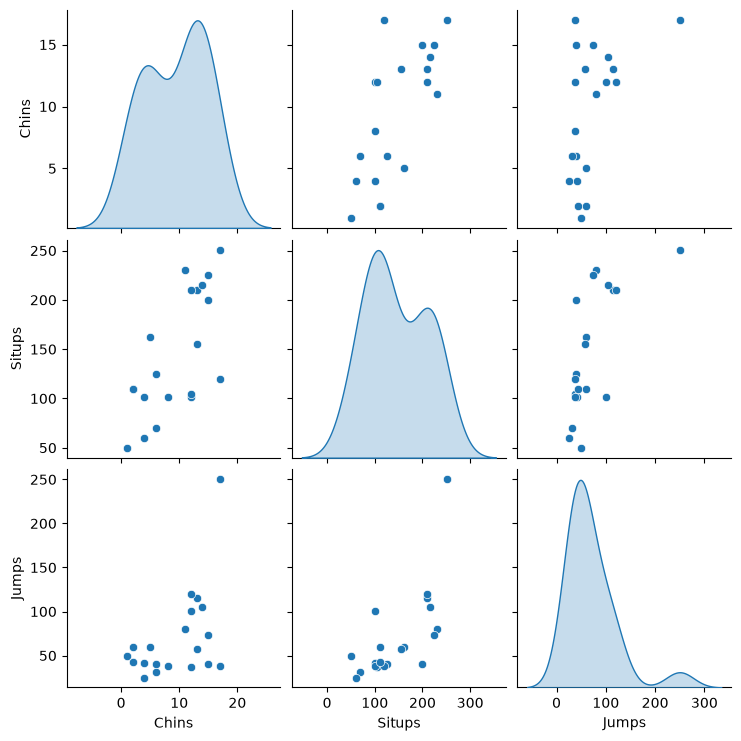

In [6]:
sns.pairplot(df, diag_kind='kde')
plt.show()

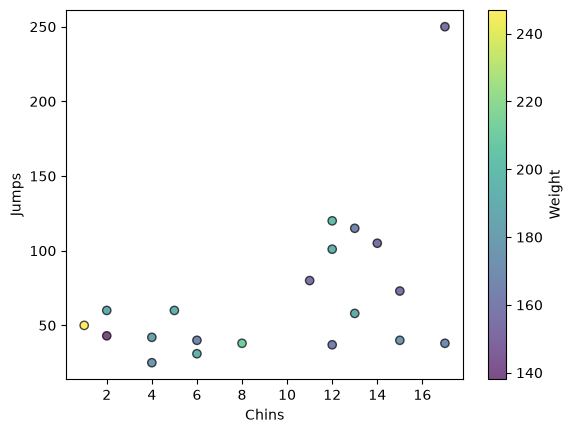

In [7]:
# Scatter of two exercise features, colored by the Weight target
scatter = plt.scatter(x.iloc[:, 0], x.iloc[:, 2], c=y["Weight"],
                      cmap='viridis', edgecolor='k', alpha=0.7)

plt.xlabel(x.columns[0])   # Chins
plt.ylabel(x.columns[2])   # Jumps
plt.colorbar(scatter, label='Weight')
plt.show()

In [8]:
df.head()

,Chins,Situps,Jumps
0,5.0,162.0,60.0
1,2.0,110.0,60.0
2,12.0,101.0,101.0
3,12.0,105.0,37.0
4,13.0,155.0,58.0


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3, 3)","[[ 0.45,-0.32, 0.09], [-0.08,-0.05, 0.03], [-0.48, 0.09,-0.05]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Chins','Situps','Jumps']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](3,)","[210.18, 40.92, 52.01]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [12]:
preds = model.predict(x_test)

In [13]:
# Compare predictions vs actual values in an aligned DataFrame
pred_df = pd.DataFrame(preds, columns=y_test.columns, index=y_test.index)

print("Predicted:")
print(pred_df.head())
print("\nActual:")
print(y_test.head())

Predicted:
        Weight      Waist      Pulse
0   166.299446  34.349313  61.692687
17  149.165443  31.140784  64.132980
15  159.626702  33.151725  59.782455
1   181.509420  37.106506  58.293805

Actual:
    Weight  Waist  Pulse
0    191.0   36.0   50.0
17   157.0   32.0   52.0
15   202.0   37.0   62.0
1    189.0   37.0   52.0


In [16]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# The three targets (Weight, Waist, Pulse) have very different scales, so we
# report metrics per target rather than averaging them into one number.
r2 = r2_score(y_test, preds, multioutput="raw_values")
rmse = np.sqrt(mean_squared_error(y_test, preds, multioutput="raw_values"))

for name, r, e in zip(y_test.columns, r2, rmse):
    print(f"{name:<8} R^2: {r:7.3f}   RMSE: {e:7.3f}")


Weight   R^2:  -1.243   RMSE:  25.115
Waist    R^2:  -0.076   RMSE:   2.138
Pulse    R^2:  -2.732   RMSE:   9.062
